## Laboratorium 10

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az


### Historia:

W miejskim przedsiębiorstwie komunikacyjnym odkryto, że nowe autobusy elektryczne zużywają więcej energii niż powinny. Zużycie paliwa rośnie liniowo wraz z liczbą  - większa masa -> większe spalanie.

Podejrzenie, że psują się akumulatory, gdyż spalanie zwiększyło się przy podobnej ilości pasażerów.

Generowanie danych:

In [18]:
np.random.seed(123)

n_days = 26
days = np.arange(1, n_days + 1)

passengers = np.random.randint(15, 80, n_days)

true_failure_day = 13
base_before_failure = 25
base_after_failure = 30
p_before_failure = 0.3
p_after_failure = 0.5

fuel_consumption = np.zeros(n_days)
for i in range(n_days):
    if i < true_failure_day:
        fuel_consumption[i] = base_before_failure + p_before_failure * passengers[i] + np.random.normal(0, 1.5)
    else:
        fuel_consumption[i] = base_after_failure + p_after_failure * passengers[i] + np.random.normal(0, 2)


C:\Users\jasin\AppData\Local\Temp\ipykernel_10300\2456125295.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


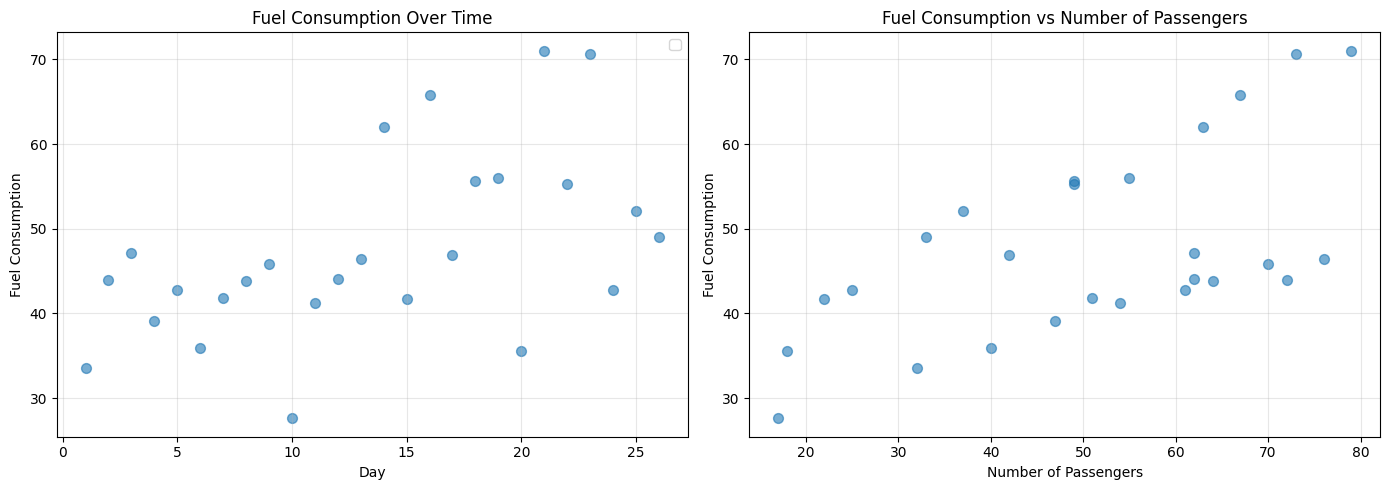

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(days, fuel_consumption, alpha=0.6, s=50)
ax1.set_xlabel('Day')
ax1.set_ylabel('Fuel Consumption')
ax1.set_title('Fuel Consumption Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(passengers, fuel_consumption, alpha=0.6, s=50)
ax2.set_xlabel('Number of Passengers')
ax2.set_ylabel('Fuel Consumption')
ax2.set_title('Fuel Consumption vs Number of Passengers')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Model:

In [20]:
with pm.Model() as bus_model:
    # przed awarią
    b_1 = pm.Uniform("b_1", lower=0.1, upper=1.0) 
    # po awarii
    b_2 = pm.Uniform("b_2", lower=0.1, upper=1.0)  
    
    # bazowe zużycie paliwa, które mogło się zmienić
    base_1 = pm.Uniform("base_1", lower=20, upper=40)  
    base_2 = pm.Uniform("base_2", lower=20, upper=40)
    
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_days - 1)
    idx = np.arange(n_days)
    b = pm.math.switch(tau > idx, b_1, b_2)
    base = pm.math.switch(tau > idx, base_1, base_2)
    
    m_fuel = pm.Deterministic("m_fuel", base + b * passengers)
    sigma_fuel = pm.Uniform("sigma_fuel", lower=0.5, upper=5)
    
    fuel_obs = pm.Normal("fuel_obs", mu=m_fuel, sigma=sigma_fuel, observed=fuel_consumption)
    
    trace = pm.sample(2000, tune=1000, cores=2, return_inferencedata=True, random_seed=42, target_accept=0.95)

c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:954: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [b_1, b_2, base_1, base_2, sigma_fuel]
>Metropolis: [tau]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 159 seconds.
c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
We recommend running at least 4 chains for robust computation of convergence diagnostics


Analiza wyników:

c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
c:\Users\jasin\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz\stats\diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
b_1          0.317  0.035   0.253    0.381      0.001    0.001    1677.0   
b_2          0.549  0.032   0.490    0.609      0.001    0.001    1693.0   
base_1      23.754  1.948  20.060   26.940      0.048    0.044    1584.0   
base_2      28.342  1.640  25.375   31.362      0.040    0.045    1687.0   
tau         13.000  0.000  13.000   13.000      0.000      NaN    4000.0   
sigma_fuel   2.152  0.350   1.525    2.774      0.008    0.009    2144.0   

            ess_tail  r_hat  
b_1           1724.0    1.0  
b_2           1642.0    1.0  
base_1        1285.0    1.0  
base_2        1682.0    1.0  
tau           4000.0    NaN  
sigma_fuel    1615.0    1.0  


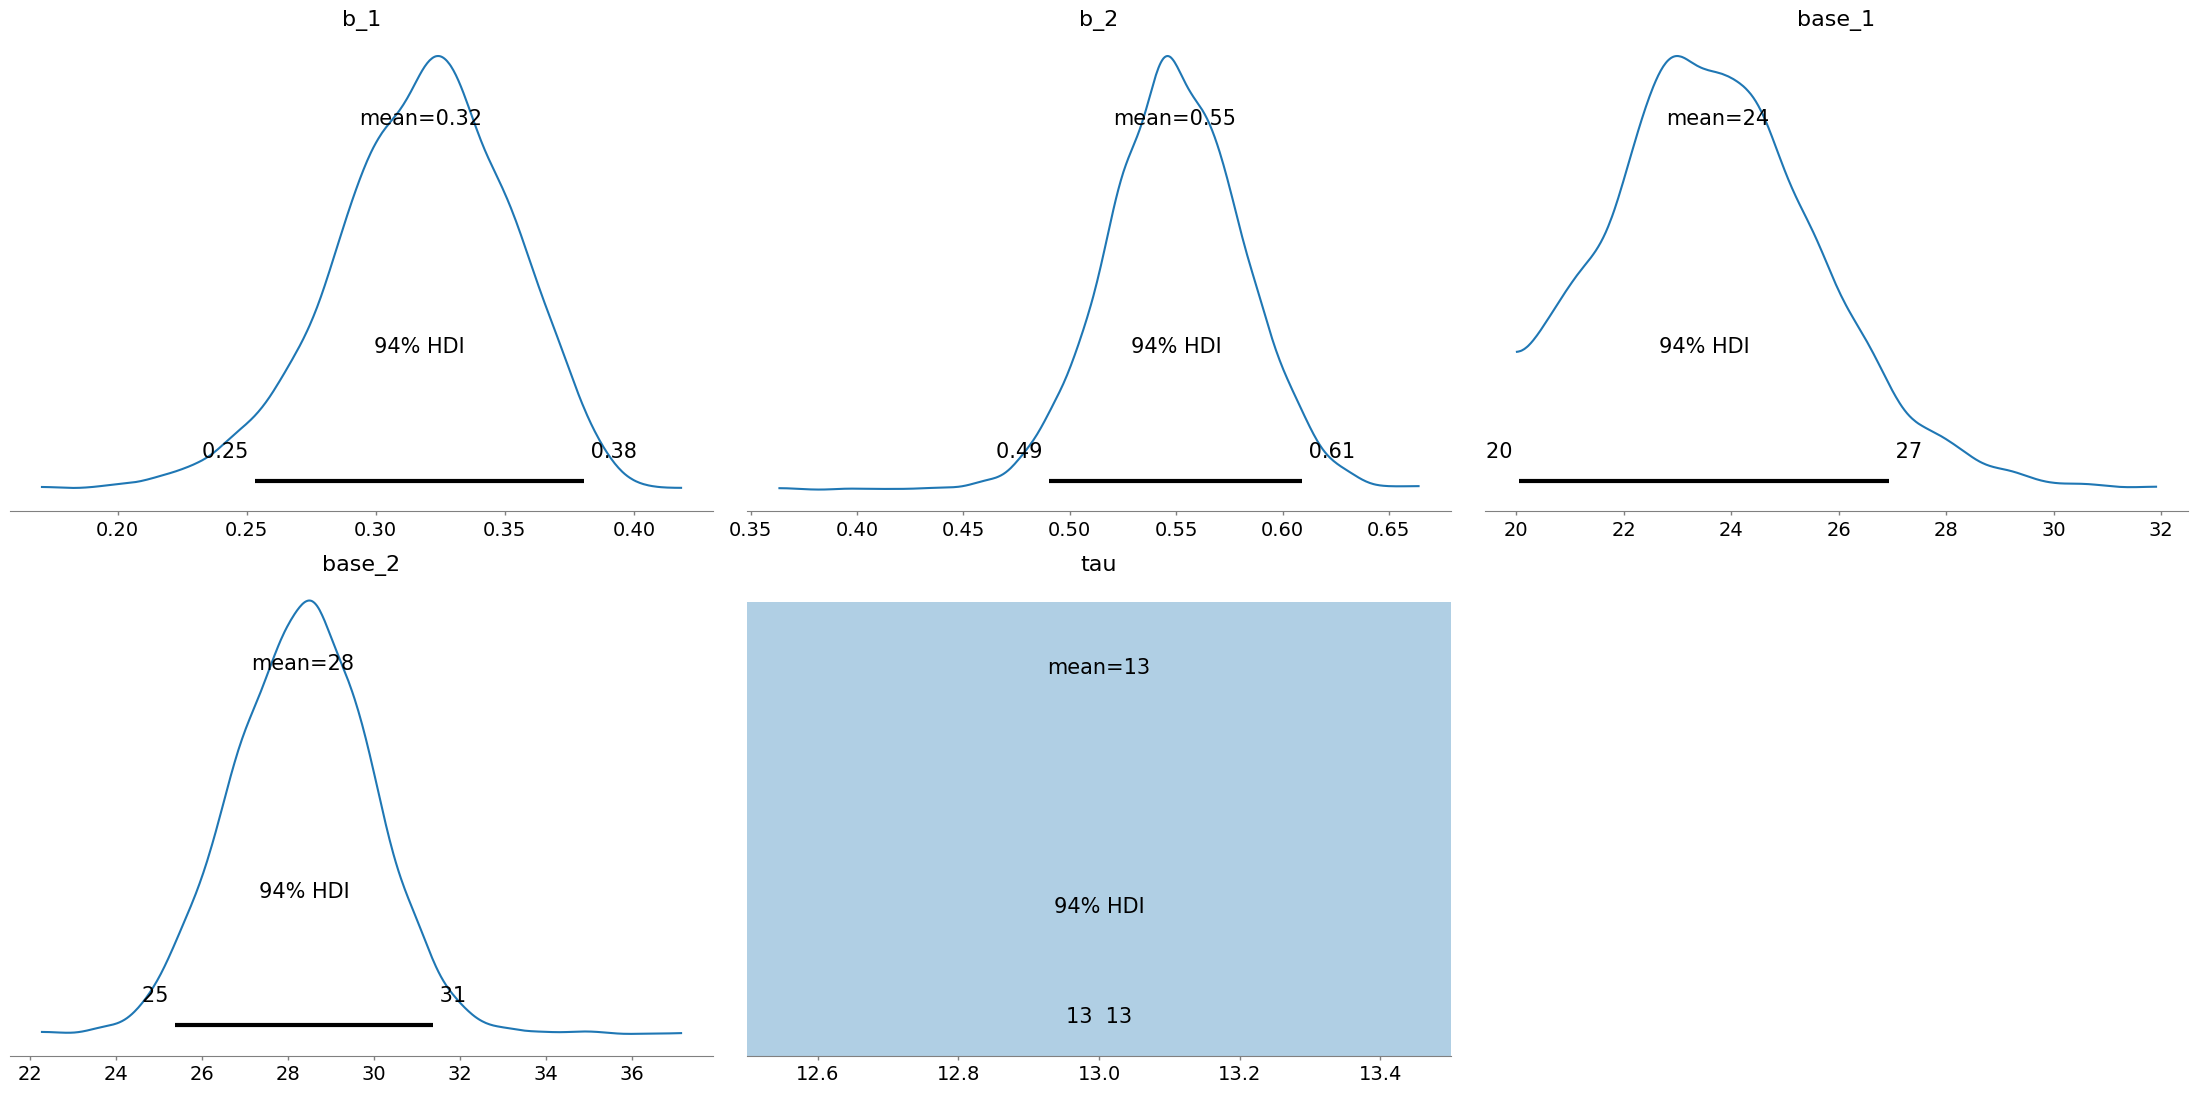

Tau (dzień zepsucia) 13
Średnia: 13.0
Prawdziwy dzień awarii: 13


In [21]:
summary = az.summary(trace, var_names=["b_1", "b_2", "base_1", "base_2", "tau", "sigma_fuel"])
print(summary)

tau_samples = trace.posterior["tau"].values.flatten()
tau_estimate = int(np.median(tau_samples))
tau_mean = np.mean(tau_samples)
az.plot_posterior(trace, var_names=["b_1", "b_2", "base_1", "base_2", "tau"], hdi_prob=0.94)
plt.tight_layout()
plt.show()

print(f"Tau (dzień zepsucia) {tau_estimate}")
print(f"Średnia: {tau_mean:.1f}")
print(f"Prawdziwy dzień awarii: {true_failure_day}")

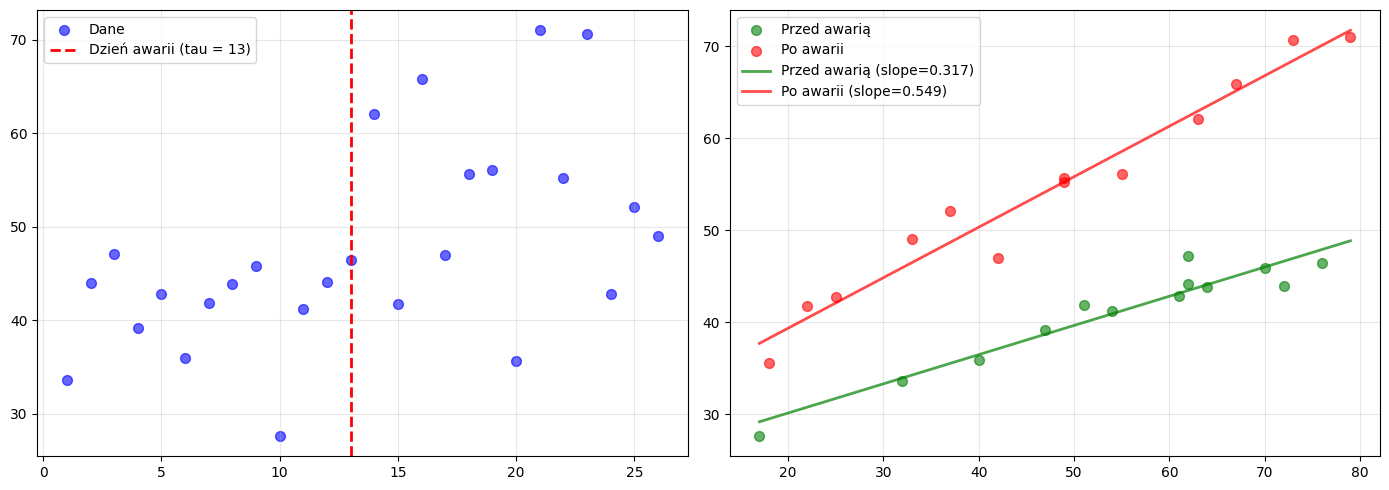

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(days, fuel_consumption, alpha=0.6, s=50, label='Dane', color='blue')
ax1.axvline(x=tau_estimate, color='red', linestyle='--', linewidth=2, label=f'Dzień awarii (tau = {tau_estimate})')
# ax1.axvline(x=true_failure_day, color='green', linestyle='--', linewidth=2, label=f'True failure (day {true_failure_day})')

b1_mean = trace.posterior["b_1"].mean().values
b2_mean = trace.posterior["b_2"].mean().values
base1_mean = trace.posterior["base_1"].mean().values
base2_mean = trace.posterior["base_2"].mean().values

days_before = days[days <= tau_estimate]
days_after = days[days > tau_estimate]
passengers_before = passengers[days <= tau_estimate]
passengers_after = passengers[days > tau_estimate]

fuel_before = base1_mean + b1_mean * passengers_before
fuel_after = base2_mean + b2_mean * passengers_after

# ax1.plot(days_before, fuel_before, 'g-', linewidth=2, alpha=0.7, label='Model before failure')
# ax1.plot(days_after, fuel_after, 'r-', linewidth=2, alpha=0.7, label='Model after failure')

ax1.legend()
ax1.grid(True, alpha=0.3)

passengers_sorted = np.sort(passengers)
# wzór przed awaraią
fuel_model_before = base1_mean + b1_mean * passengers_sorted
# wzór po awarii
fuel_model_after = base2_mean + b2_mean * passengers_sorted

ax2.scatter(passengers[:tau_estimate], fuel_consumption[:tau_estimate], 
           alpha=0.6, s=50, label='Przed awarią', color='green')
ax2.scatter(passengers[tau_estimate:], fuel_consumption[tau_estimate:], 
           alpha=0.6, s=50, label='Po awarii', color='red')
ax2.plot(passengers_sorted, fuel_model_before, 'g-', linewidth=2, alpha=0.7, 
        label=f'Przed awarią (slope={b1_mean:.3f})')
ax2.plot(passengers_sorted, fuel_model_after, 'r-', linewidth=2, alpha=0.7, 
        label=f'Po awarii (slope={b2_mean:.3f})')

ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()